In [76]:
"""COE 311K Final

Alan Ji ayj333

Zachary Matthews zrm494

"""

pass

In [77]:
import numpy as np
import matplotlib.pyplot as plt

In [78]:
M = 1442.87/4  # mass (kg)
C = 2659.81    # dampening coefficient (N*s/m)
K = 78450.0    # spring constant (N/m)

zetta = 0.25   # dampening ratio

Y_0 = 0.0762   # meters
V_0 = 0


def f(y, v):# second order
    return (-C*v-K*y)/M

In [79]:
import math
def analytical(t):
    w_n = math.sqrt(K/M)
    w_d = w_n * math.sqrt(1-zetta**2)
    B = (V_0 + zetta*w_n*Y_0)/w_d
    return math.exp(zetta*w_n*t) * (Y_0*math.cos(w_d*t))

In [82]:
def euler_forward(step):
    # Define parameters
    h = step  # step size
    t_start, t_end = 0, 1
    num_steps = int((t_end - t_start) / h)
    t_values = np.linspace(t_start, t_end, num_steps + 1)
    y_values = np.zeros(num_steps + 1)
    v_values = np.zeros(num_steps + 1)
    
    # Initial conditions
    y_values[0] = Y_0 
    v_values[0] = V_0
        
    # Implement Euler's method
    for i in range(num_steps):
        y_values[i + 1] = analytical(i*h)#y_values[i] + h * v_values[i]
        v_values[i + 1] = v_values[i] + h * f(y_values[i], v_values[i])
    
    return t_values, y_values, v_values

Text(0.5, 1.0, "Euler's Forward")

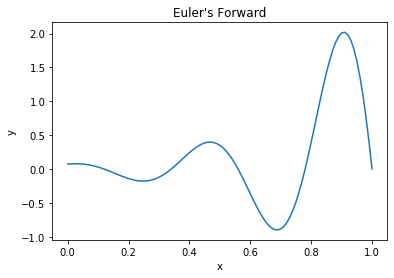

In [83]:
x_values, y_values, v = euler_forward(0.01)


plt.plot(x_values, y_values, label=f"Euler's")
plt.xlabel('x')
plt.ylabel('y')
plt.title("Euler's Forward")

In [63]:
def rk4(step):
    # Define parameters
    t_start, t_end = 0, 5
    num_steps = int((t_end - t_start) / step)
    t_values = np.linspace(t_start, t_end, num_steps + 1)
    y_values = np.zeros(num_steps + 1)
    v_values = np.zeros(num_steps + 1)

    # initial condition
    state = [Y_0, V_0]
    temp = [0, 0]
  
    # rk4 ks
    k = np.zeros((4, 2))
    
    for i in range(num_steps):
    
        k[0,0] = state[1]
        k[0,1] = f(state[0], state[1])

        temp = state + (0.5)*step*k[0,:]

        k[1,0] = temp[1]
        k[1,1] = f(state[0], state[1])

        temp = state + (0.5)*step*k[1,:]

        k[2,0] = temp[1]
        k[2,1] = f(state[0], state[1])

        temp = state + step*k[2,:]

        k[3,0] = temp[1]
        k[3,1] = f(state[0], state[1])

        state = state + (step/6.) * (k[0,:]+2.*k[1,:]+2.*k[2,:]+k[3,:])
        
        y_values[i] = state[0]
        v_values[i] = state[1]
        
    return t_values, y_values, v_values
    


Text(0.5, 1.0, 'RK4')

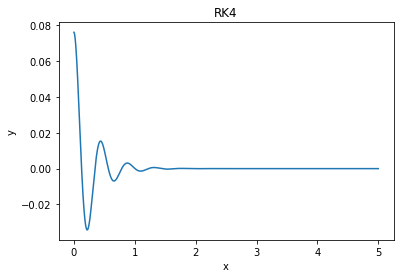

In [65]:
x_values, y_values, v = rk4(0.001)


plt.plot(x_values, y_values, label=f"Rk4")
plt.xlabel('x')
plt.ylabel('y')
plt.title("RK4")